In [16]:
import sys
sys.path.insert(0, "..")

%load_ext autoreload
%autoreload 2

import numpy as np
import torch
import matplotlib.pyplot as plt

from src.data import load_sin
from src.models import make_gp, train_mlp, make_mlp
from src.methods import mc_dropout_predict, train_ensemble, ensemble_predict, laplace_predict, train_vi, vi_predict
from src.plotting import plot_uncertainty_for_1d_data

np.random.seed(42)
torch.manual_seed(42)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Data

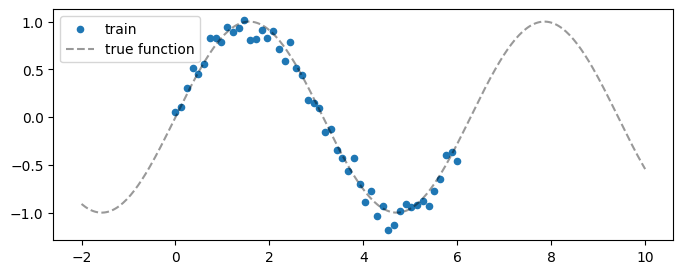

In [17]:
X_train, y_train, X_eval, y_eval, _ = load_sin()

fig, ax = plt.subplots(figsize=(8, 3))
ax.scatter(X_train, y_train, s=20, label="train")
ax.plot(X_eval, y_eval, "k--", alpha=0.4, label="true function")
ax.legend()
plt.show()

## Laplace Approximation
aproksymacja Laplaca na ostatniej warstwie

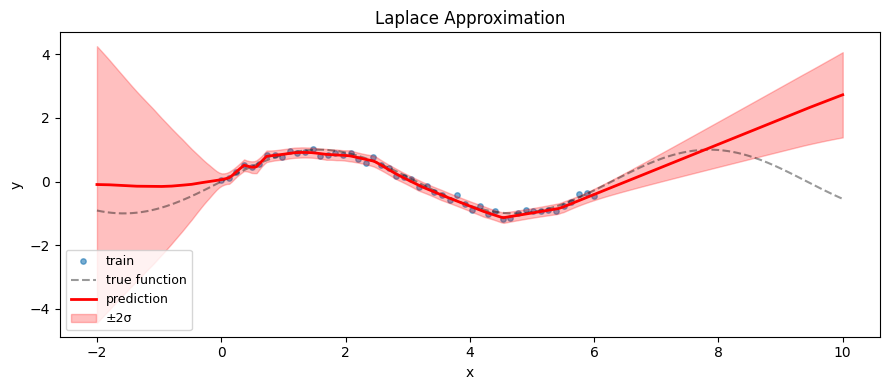

In [18]:
nn_laplace = train_mlp(X_train, y_train, epochs=1000)
y_pred, y_std = laplace_predict(nn_laplace, X_train, y_train, X_eval)
plot_uncertainty_for_1d_data(X_train, y_train, X_eval, y_eval, y_pred, y_std, "Laplace Approximation")

## Gaussian Process

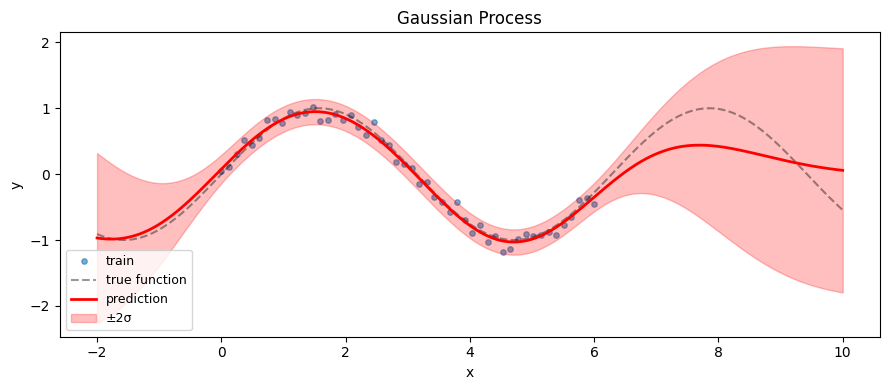

In [19]:
gp = make_gp().fit(X_train, y_train)
y_pred, y_std = gp.predict(X_eval, return_std=True)
plot_uncertainty_for_1d_data(X_train, y_train, X_eval, y_eval, y_pred, y_std, "Gaussian Process")

## Monte Carlo Dropout
(Gal & Ghahramani 2016).

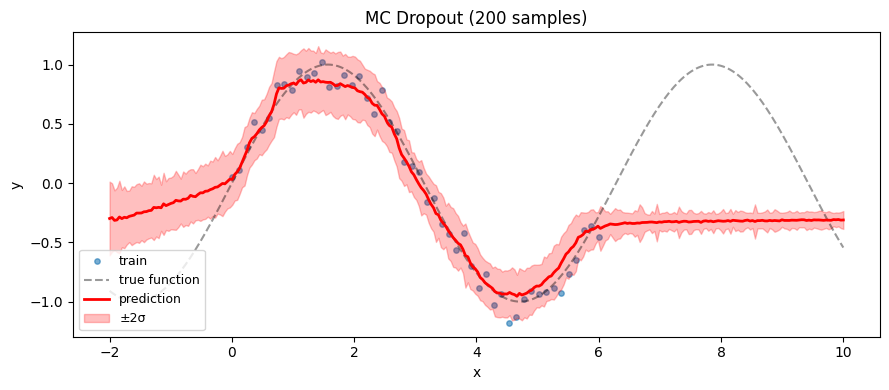

In [20]:
nn_dropout = train_mlp(X_train, y_train, dropout=0.2, epochs=1000)
y_pred, y_std = mc_dropout_predict(nn_dropout, X_eval, n_samples=200)
plot_uncertainty_for_1d_data(X_train, y_train, X_eval, y_eval, y_pred, y_std, "MC Dropout (200 samples)")

## Deep Ensemble


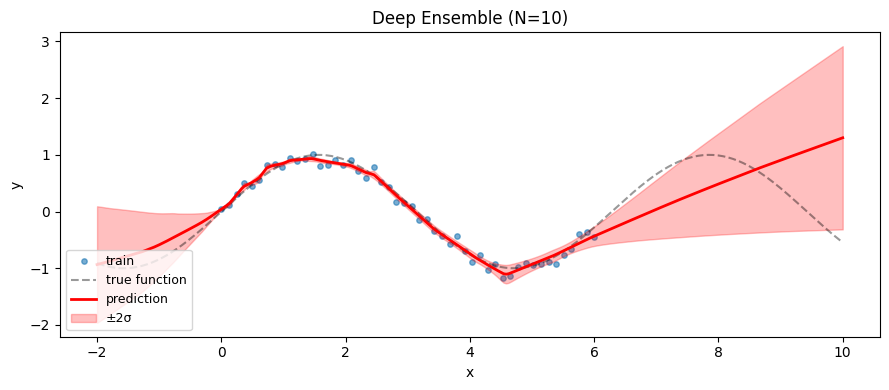

In [21]:
ensemble = train_ensemble(X_train, y_train, n_models=10, epochs=1000)
y_pred, y_std = ensemble_predict(ensemble, X_eval)
plot_uncertainty_for_1d_data(X_train, y_train, X_eval, y_eval, y_pred, y_std, f"Deep Ensemble (N={len(ensemble)})")

## Variational Inference


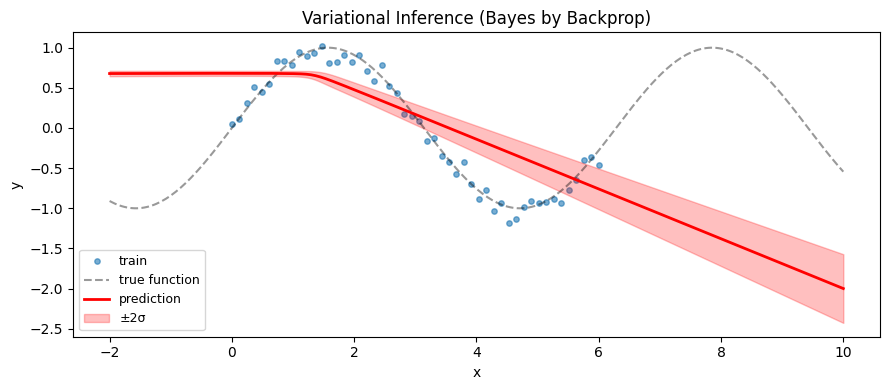

In [ ]:
vi_model = train_vi(X_train, y_train, epochs=1000)
y_pred, y_std = vi_predict(vi_model, X_eval)
plot_uncertainty_for_1d_data(X_train, y_train, X_eval, y_eval, y_pred, y_std, "Variational Inference (Bayes by Backprop)")
